# 02 — Análisis Exploratorio de Datos (EDA)

## Objetivo

Explorar el comportamiento temporal y las relaciones entre los principales
indicadores climáticos asociados al fenómeno ENSO.

Se estudiarán:

1. Cobertura temporal y calidad de los datos.
2. Evolución temporal de los indicadores.
3. Distribuciones y valores extremos.
4. Episodios históricos de El Niño y La Niña.
5. Relaciones entre indicadores.
6. Correlaciones y posible redundancia entre variables.
7. Diferencias entre el dataset histórico y el dataset moderno.

El objetivo de esta etapa es comprender los datos antes de construir
las variables predictoras y el objetivo de Machine Learning.

### Carga de los datos e importacion de librerias

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# rutas de lso datos
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

In [4]:
# carga de lso datos
historical = pd.read_csv(DATA_PROCESSED / "enso_historical.csv", parse_dates=["date"])
modern = pd.read_csv(DATA_PROCESSED / "enso_modern.csv", parse_dates=["date"])

In [5]:
historical.info()

<class 'pandas.DataFrame'>
RangeIndex: 1857 entries, 0 to 1856
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1857 non-null   datetime64[us]
 1   nino12  1857 non-null   float64       
 2   nino3   1857 non-null   float64       
 3   nino34  1857 non-null   float64       
 4   nino4   1857 non-null   float64       
 5   soi     1857 non-null   float64       
 6   tni     1857 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 101.7 KB


In [6]:
modern.info()

<class 'pandas.DataFrame'>
RangeIndex: 562 entries, 0 to 561
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    562 non-null    datetime64[us]
 1   nino12  562 non-null    float64       
 2   nino3   562 non-null    float64       
 3   nino34  562 non-null    float64       
 4   nino4   562 non-null    float64       
 5   soi     562 non-null    float64       
 6   tni     562 non-null    float64       
 7   mei     562 non-null    float64       
 8   oni     562 non-null    float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 39.6 KB


In [7]:
display(historical.head())
display(modern.head())

,date,nino12,nino3,nino34,nino4,soi,tni
0,1870-03-01,-0.65,-0.76,-0.83,-1.01,-0.75,0.834
1,1870-05-01,-0.64,-1.15,-1.27,-1.08,-0.11,0.863
2,1870-06-01,-0.96,-0.99,-1.08,-1.11,-1.10,0.612
3,1870-07-01,-0.98,-1.01,-1.04,-0.98,0.17,0.060
4,1870-08-01,-1.02,-0.89,-0.88,-0.86,0.98,-0.441


,date,nino12,nino3,nino34,nino4,soi,tni,mei,oni
0,1979-01-01,0.23,-0.09,0.05,0.18,-0.45,-0.343,0.46,0.03
1,1979-02-01,-0.58,-0.20,0.09,0.30,0.61,-0.309,0.29,0.07
2,1979-03-01,-0.25,-0.08,0.13,0.22,-0.49,-0.347,-0.05,0.20
3,1979-04-01,0.51,0.24,0.17,0.07,-0.65,-0.187,0.22,0.28
4,1979-05-01,0.27,0.08,-0.09,-0.13,0.46,0.067,0.27,0.23


## Estadistica Descriptiva

In [8]:
historical.describe().T

,count,mean,min,25%,50%,75%,max,std
date,1857,1948-02-12 10:48:16.284330,1870-03-01 00:00:00,1909-03-01 00:00:00,1948-03-01 00:00:00,1987-02-01 00:00:00,2025-12-01 00:00:00,NaN
nino12,1857.0,-0.110442,-2.34,-0.74,-0.25,0.33,4.56,0.908706
nino3,1857.0,-0.132531,-2.08,-0.7,-0.22,0.28,3.24,0.798915
nino34,1857.0,-0.096947,-2.49,-0.63,-0.16,0.35,2.57,0.773009
nino4,1857.0,-0.164604,-1.94,-0.58,-0.16,0.26,1.59,0.582388
soi,1857.0,-0.044356,-4.34,-0.78,-0.03,0.75,4.07,1.136821
tni,1857.0,-0.125637,-2.674,-0.839,-0.134,0.464,4.638,1.032264


In [9]:
modern.describe().T

,count,mean,min,25%,50%,75%,max,std
date,562,2002-06-03 08:52:57.224199,1979-01-01 00:00:00,1990-09-08 12:00:00,2002-06-16 00:00:00,2014-02-22 00:00:00,2025-12-01 00:00:00,NaN
nino12,562.0,0.005872,-1.96,-0.6475,-0.23,0.36,4.56,1.05712
nino3,562.0,0.031228,-1.86,-0.5575,-0.09,0.4275,3.24,0.889429
nino34,562.0,0.024964,-2.18,-0.5575,-0.04,0.49,2.57,0.856882
nino4,562.0,0.052331,-1.65,-0.36,0.135,0.52,1.59,0.624501
soi,562.0,-0.166263,-3.46,-0.8475,-0.12,0.61,3.02,1.122082
tni,562.0,-0.43576,-2.674,-1.31075,-0.706,0.22175,4.638,1.311906
mei,562.0,-0.074235,-2.42,-0.77,-0.145,0.47,2.85,0.972923
oni,562.0,0.046388,-1.85,-0.5275,-0.045,0.53,2.75,0.847853


Empezar por nino 3.4

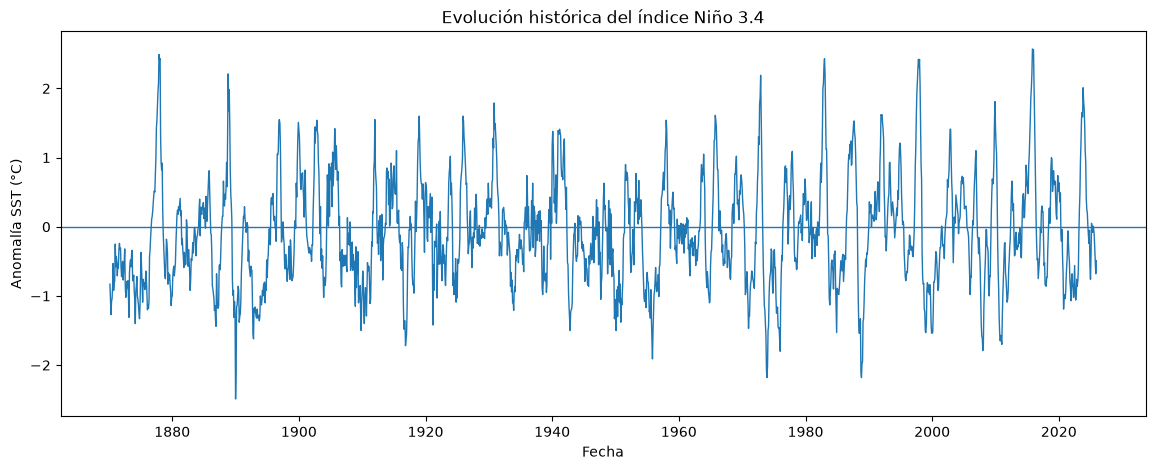

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    historical["date"],
    historical["nino34"],
    linewidth=1
)

ax.axhline(0, linewidth=1)

ax.set_title("Evolución histórica del índice Niño 3.4")
ax.set_xlabel("Fecha")
ax.set_ylabel("Anomalía SST (°C)")

plt.show()

Valores mayores a cero indican calentamiento respecto a climatologia y valores menores a cero indican enfriamiento con respecto a climatologia.

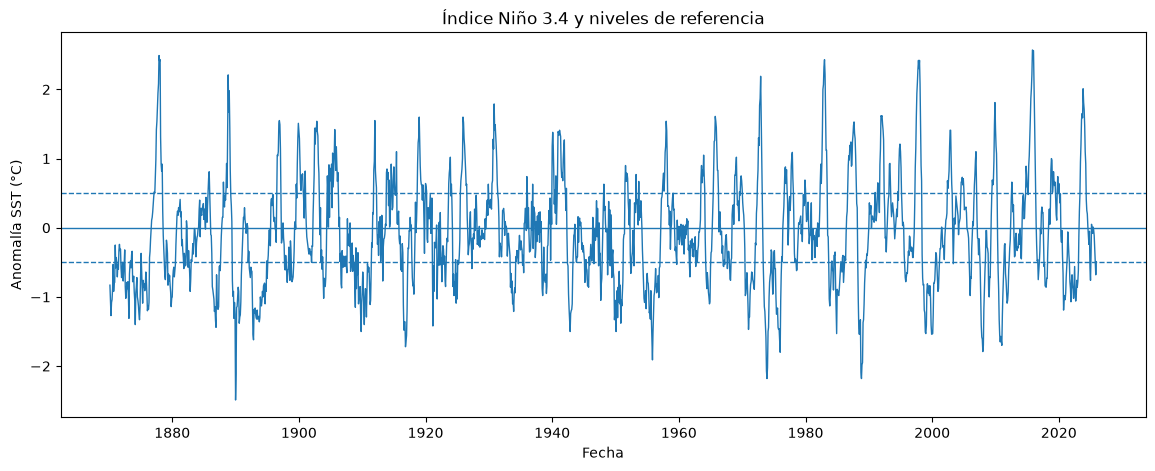

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    historical["date"],
    historical["nino34"],
    linewidth=1
)

ax.axhline(0, linewidth=1)
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.axhline(-0.5, linestyle="--", linewidth=1)

ax.set_title("Índice Niño 3.4 y niveles de referencia")
ax.set_xlabel("Fecha")
ax.set_ylabel("Anomalía SST (°C)")

plt.show()

Componente atmosferico SOI

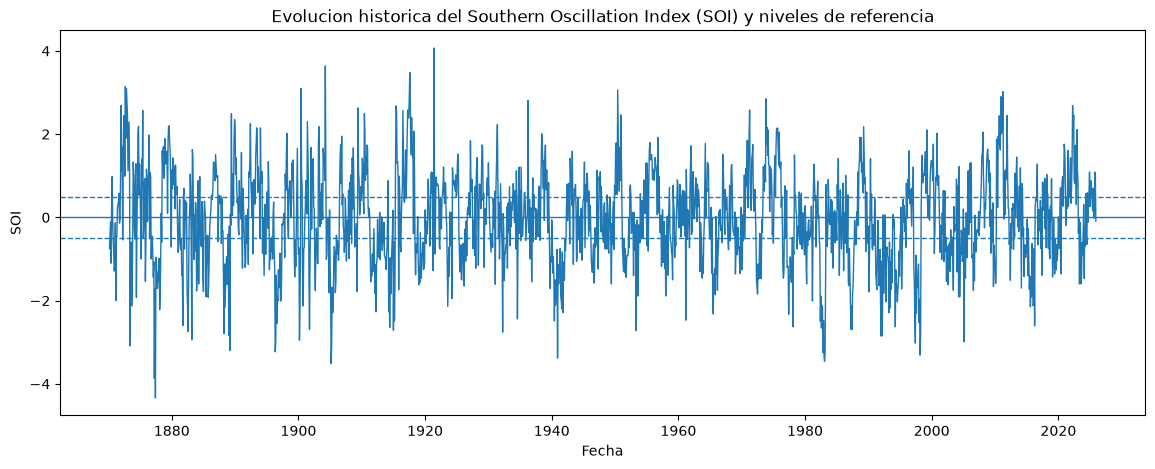

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    historical["date"],
    historical["soi"],
    linewidth=1
)

ax.axhline(0, linewidth=1)
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.axhline(-0.5, linestyle="--", linewidth=1)

ax.set_title("Evolucion historica del Southern Oscillation Index (SOI) y niveles de referencia")
ax.set_xlabel("Fecha")
ax.set_ylabel("SOI")

plt.show()

Comparacion de SOI con nino3.4

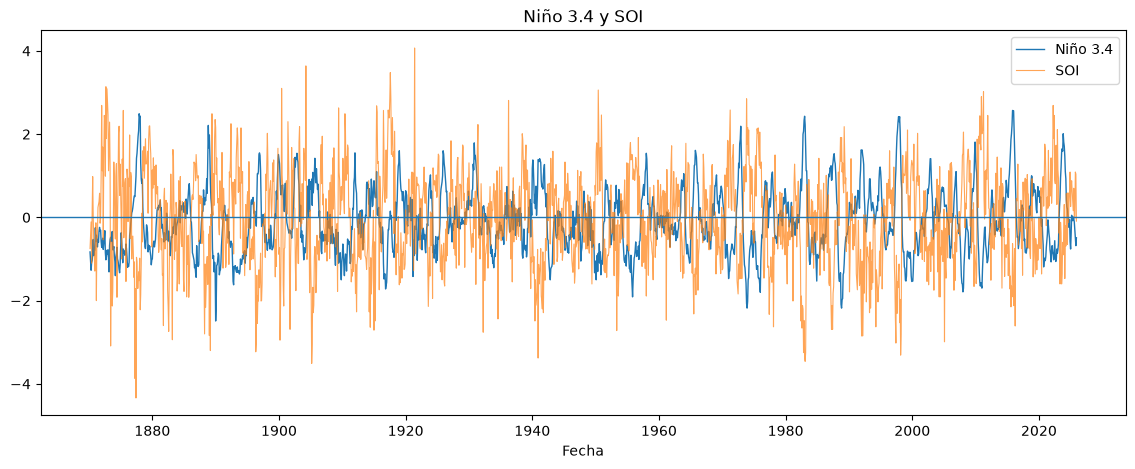

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    historical["date"],
    historical["nino34"],
    label="Niño 3.4",
    linewidth=1
)

ax.plot(
    historical["date"],
    historical["soi"],
    label="SOI",
    linewidth=0.8,
    alpha=0.7
)

ax.axhline(0, linewidth=1)

ax.set_title("Niño 3.4 y SOI")
ax.set_xlabel("Fecha")
ax.legend()

plt.show()

### Distribuciones de las variables

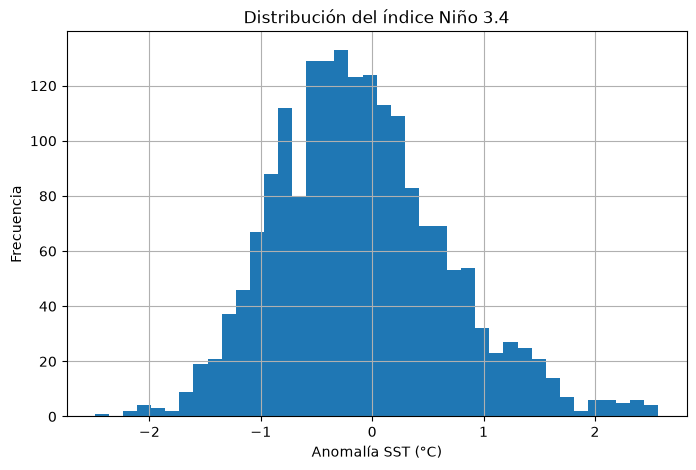

In [15]:
historical["nino34"].hist(
    bins=40,
    figsize=(8, 5)
)

plt.title("Distribución del índice Niño 3.4")
plt.xlabel("Anomalía SST (°C)")
plt.ylabel("Frecuencia")

plt.show()

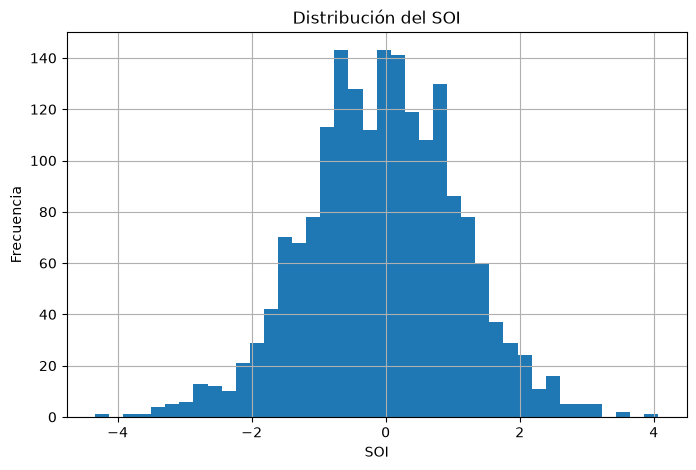

In [16]:
historical["soi"].hist(
    bins=40,
    figsize=(8, 5)
)

plt.title("Distribución del SOI")
plt.xlabel("SOI")
plt.ylabel("Frecuencia")

plt.show()

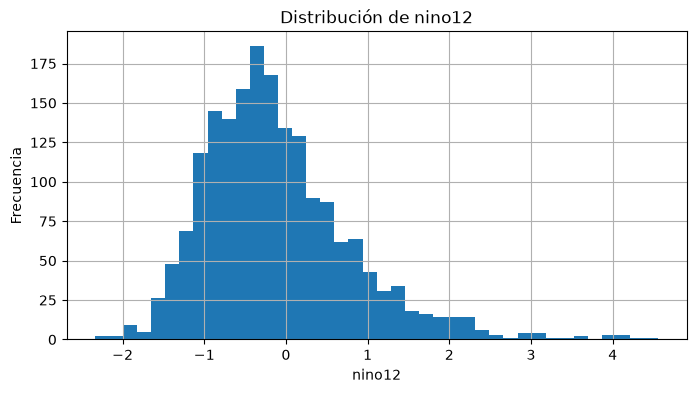

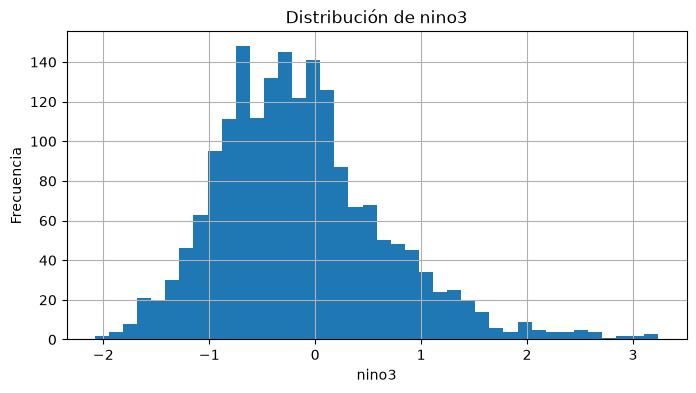

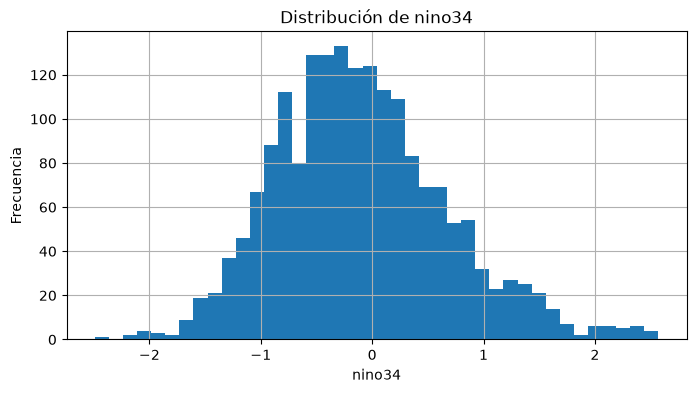

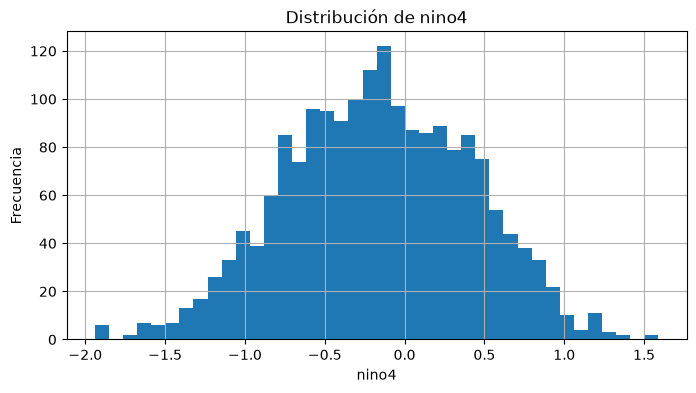

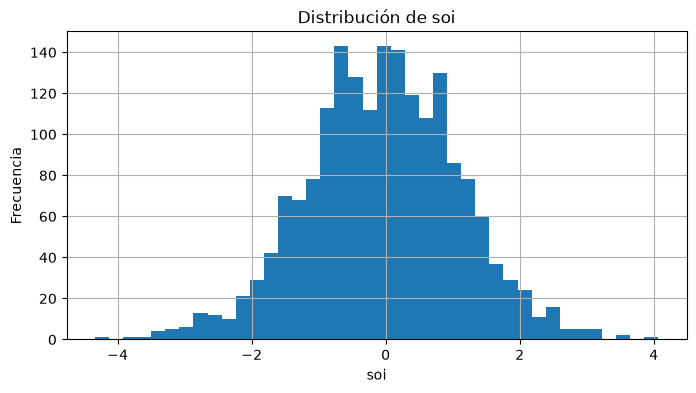

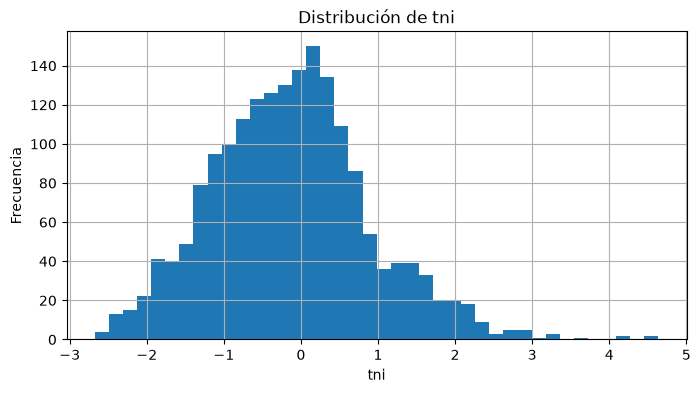

In [17]:
historical_variables = [
    "nino12",
    "nino3",
    "nino34",
    "nino4",
    "soi",
    "tni"
]

for variable in historical_variables:

    historical[variable].hist(
        bins=40,
        figsize=(8, 4)
    )

    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.show()

### Eventos ENSO conocidos

observar tres episodios

1982-1983

1997-1998

2015-2016


In [18]:
def plot_period(df, start, end, variables):
    subset = df[
        df["date"].between(start, end)
    ]

    fig, ax = plt.subplots(figsize=(12, 5))

    for variable in variables:
        ax.plot(
            subset["date"],
            subset[variable],
            label=variable,
            marker="o",
            markersize=3
        )

    ax.axhline(0, linewidth=1)

    ax.set_title(f"Indicadores ENSO: {start} → {end}")
    ax.set_xlabel("Fecha")
    ax.legend()

    plt.show()

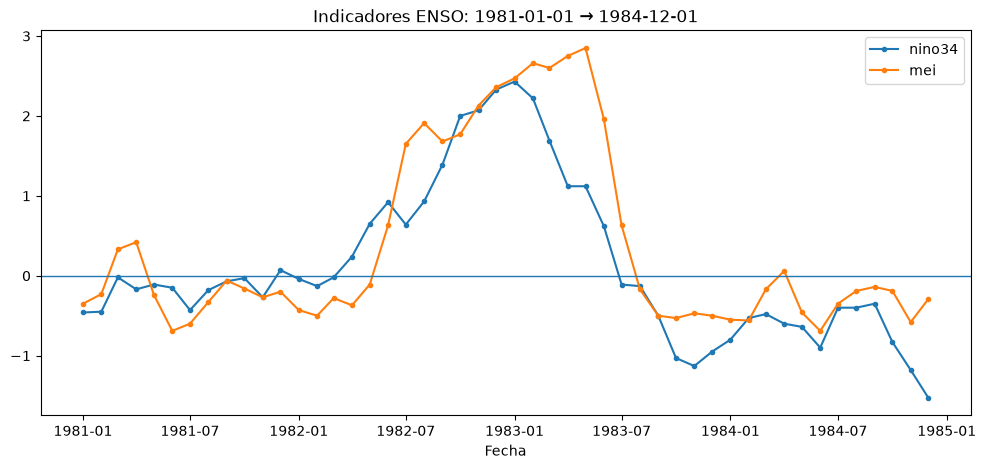

In [19]:
plot_period(
    modern,
    "1981-01-01",
    "1984-12-01",
    ["nino34", "mei"]
)

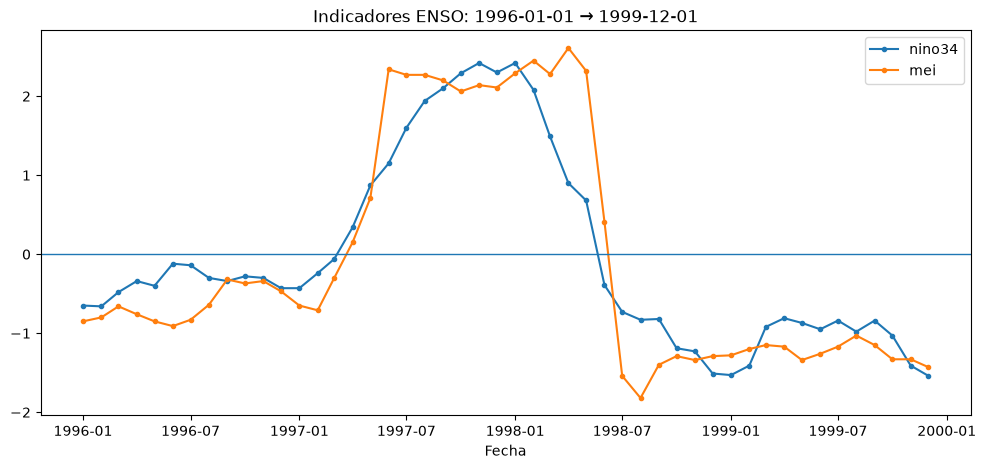

In [20]:
plot_period(
    modern,
    "1996-01-01",
    "1999-12-01",
    ["nino34", "mei"]
)

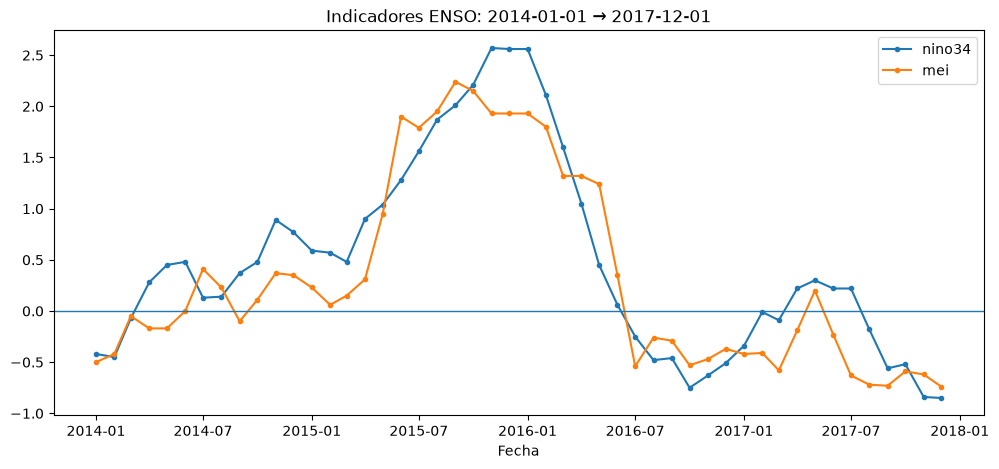

In [21]:
plot_period(
    modern,
    "2014-01-01",
    "2017-12-01",
    ["nino34", "mei"]
)

Que paso con ONI en esos eventos.

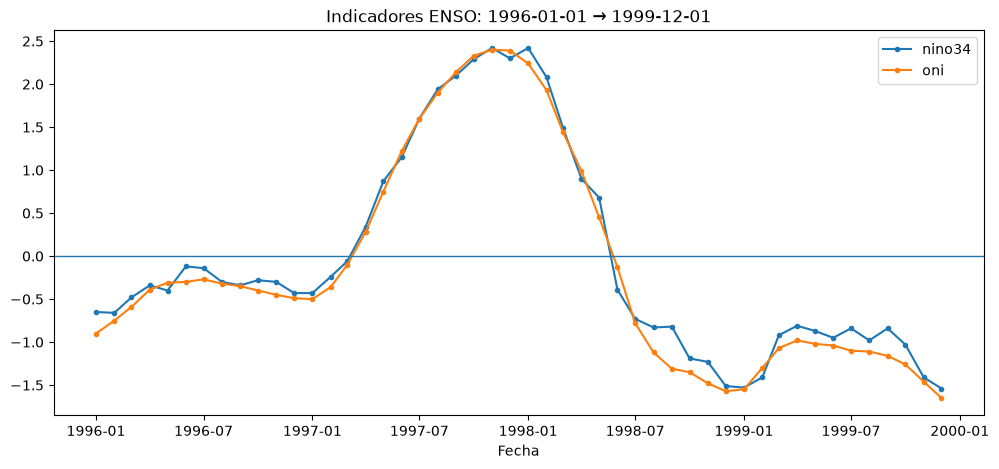

In [22]:
plot_period(
    modern,
    "1996-01-01",
    "1999-12-01",
    ["nino34", "oni"]
)

Sera que la reclacion de ONI con nino34 es redundante?

### Analisis de correlacion

correlacion historico

In [23]:
corr_historical = historical[
    historical_variables
].corr()

corr_historical.round(2)

,nino12,nino3,nino34,nino4,soi,tni
nino12,1.00,0.84,0.70,0.53,-0.43,0.38
nino3,0.84,1.00,0.95,0.80,-0.54,-0.01
nino34,0.70,0.95,1.00,0.91,-0.58,-0.24
nino4,0.53,0.80,0.91,1.00,-0.56,-0.49
soi,-0.43,-0.54,-0.58,-0.56,1.00,0.17
tni,0.38,-0.01,-0.24,-0.49,0.17,1.00


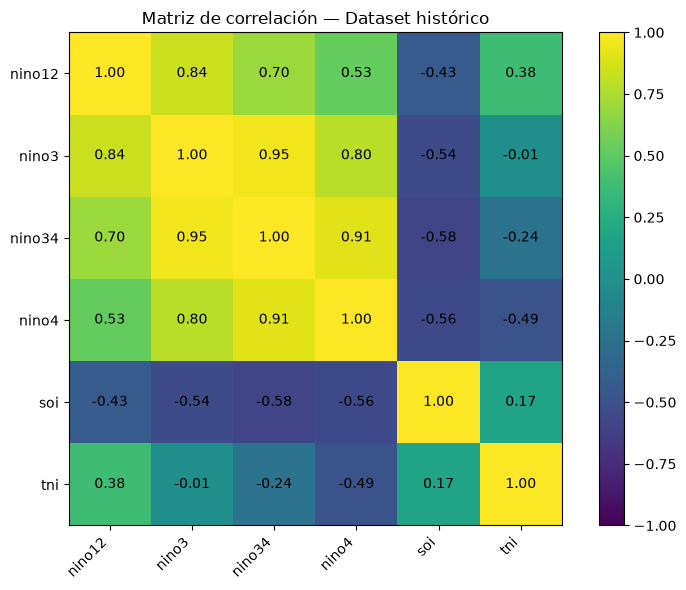

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    corr_historical,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr_historical.columns)))
ax.set_xticklabels(
    corr_historical.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(corr_historical.columns)))
ax.set_yticklabels(corr_historical.columns)

for i in range(len(corr_historical.columns)):
    for j in range(len(corr_historical.columns)):
        ax.text(
            j,
            i,
            f"{corr_historical.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(im)

ax.set_title("Matriz de correlación — Dataset histórico")

plt.tight_layout()
plt.show()

correlacion moderno

In [25]:
modern_variables = [
    "nino12",
    "nino3",
    "nino34",
    "nino4",
    "soi",
    "tni",
    "mei",
    "oni"
]

corr_modern = modern[
    modern_variables
].corr()

corr_modern.round(2)

,nino12,nino3,nino34,nino4,soi,tni,mei,oni
nino12,1.00,0.86,0.69,0.47,-0.46,0.49,0.69,0.69
nino3,0.86,1.00,0.95,0.78,-0.62,0.09,0.84,0.93
nino34,0.69,0.95,1.00,0.92,-0.69,-0.18,0.88,0.98
nino4,0.47,0.78,0.92,1.00,-0.66,-0.48,0.79,0.90
soi,-0.46,-0.62,-0.69,-0.66,1.00,0.17,-0.76,-0.70
tni,0.49,0.09,-0.18,-0.48,0.17,1.00,-0.07,-0.18
mei,0.69,0.84,0.88,0.79,-0.76,-0.07,1.00,0.89
oni,0.69,0.93,0.98,0.90,-0.70,-0.18,0.89,1.00


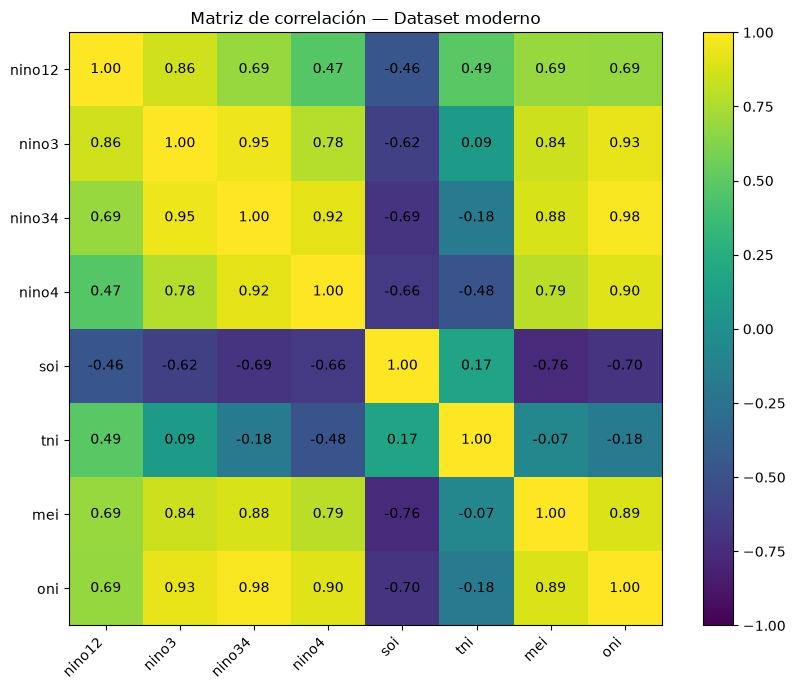

In [26]:
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    corr_modern,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr_modern.columns)))
ax.set_xticklabels(
    corr_modern.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(corr_modern.columns)))
ax.set_yticklabels(corr_modern.columns)

for i in range(len(corr_modern.columns)):
    for j in range(len(corr_modern.columns)):
        ax.text(
            j,
            i,
            f"{corr_modern.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(im)

ax.set_title("Matriz de correlación — Dataset moderno")

plt.tight_layout()
plt.show()

### estadistica bivariante

scatterplot de nino 3.4 con SOI

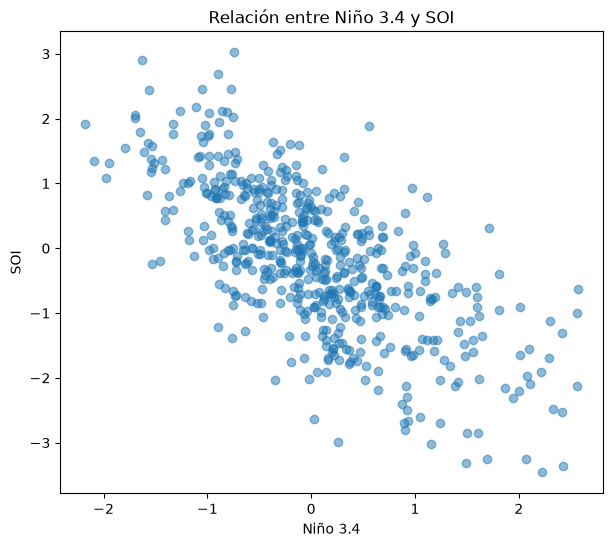

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    modern["nino34"],
    modern["soi"],
    alpha=0.5
)

ax.set_title("Relación entre Niño 3.4 y SOI")
ax.set_xlabel("Niño 3.4")
ax.set_ylabel("SOI")

plt.show()

correlacion negativa

In [28]:
modern[["nino34", "soi"]].corr()

,nino34,soi
nino34,1.000000,-0.690884
soi,-0.690884,1.000000


nino 3.4 con MEI

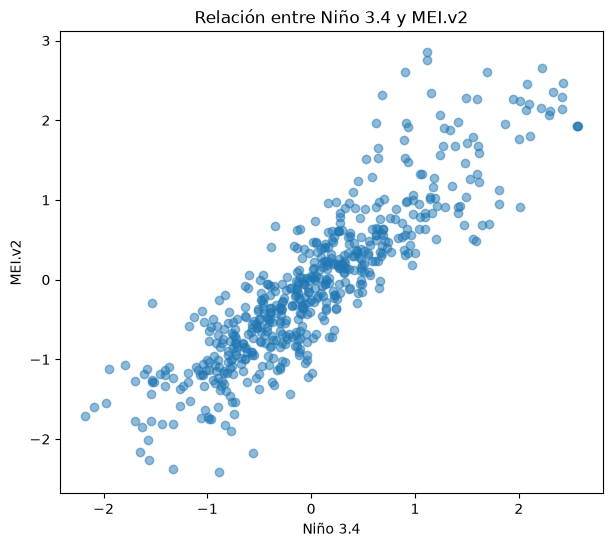

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    modern["nino34"],
    modern["mei"],
    alpha=0.5
)

ax.set_title("Relación entre Niño 3.4 y MEI.v2")
ax.set_xlabel("Niño 3.4")
ax.set_ylabel("MEI.v2")

plt.show()

In [30]:
modern[["nino34", "mei"]].corr()

,nino34,mei
nino34,1.000000,0.882212
mei,0.882212,1.000000


### Se puede establecer una tendencia a largo plazo

media movil de 12 meses para visualizar

In [31]:
historical["nino34_ma12"] = (
    historical["nino34"]
    .rolling(window=12)
    .mean()
)

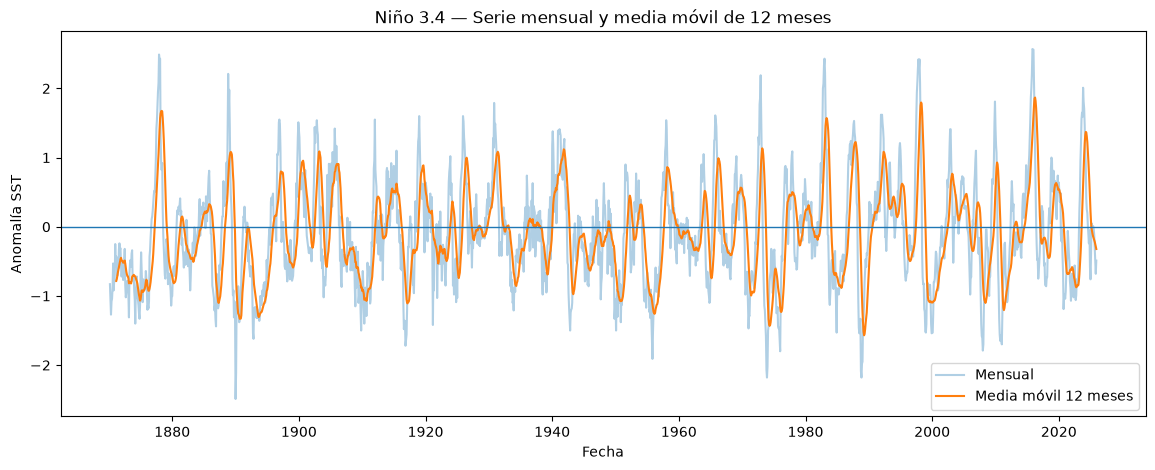

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    historical["date"],
    historical["nino34"],
    alpha=0.35,
    label="Mensual"
)

ax.plot(
    historical["date"],
    historical["nino34_ma12"],
    linewidth=1.5,
    label="Media móvil 12 meses"
)

ax.axhline(0, linewidth=1)

ax.set_title("Niño 3.4 — Serie mensual y media móvil de 12 meses")
ax.set_xlabel("Fecha")
ax.set_ylabel("Anomalía SST")
ax.legend()

plt.show()

### Series temporales: Estudio de autocorrelacion

Estudio de autocorrelacion

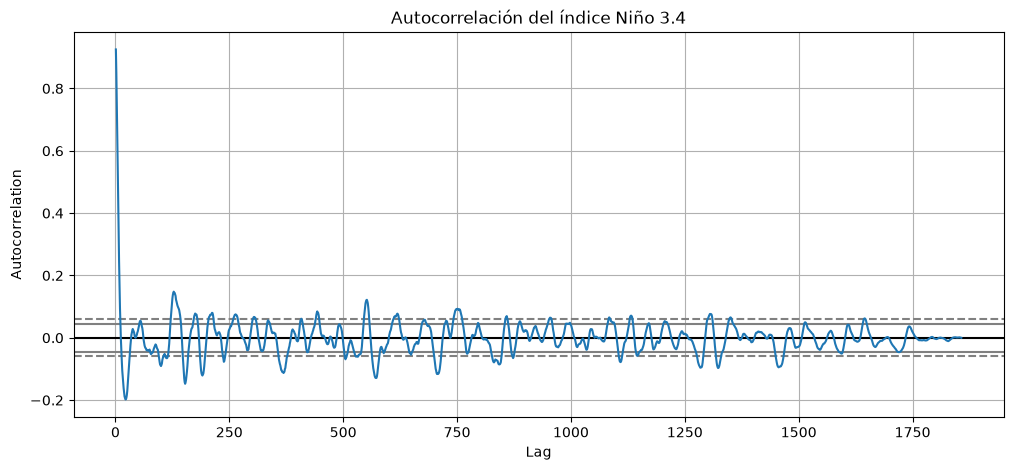

In [33]:
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(figsize=(12, 5))

autocorrelation_plot(
    historical.set_index("date")["nino34"],
    ax=ax
)

ax.set_title("Autocorrelación del índice Niño 3.4")

plt.show()

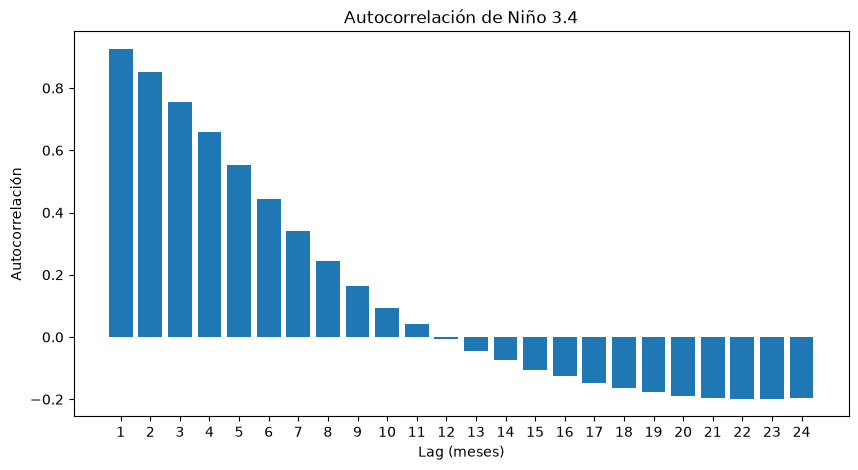

In [34]:
# autocorrelacion de los primeros 24 meses
lags = range(1, 25)

autocorr_nino34 = [
    historical["nino34"].autocorr(lag=lag)
    for lag in lags
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(lags, autocorr_nino34)

ax.set_title("Autocorrelación de Niño 3.4")
ax.set_xlabel("Lag (meses)")
ax.set_ylabel("Autocorrelación")
ax.set_xticks(range(1, 25))

plt.show()

In [35]:
for lag in [1, 2, 3, 6, 9, 12]:
    print(
        f"Lag {lag:2d}: "
        f"{historical['nino34'].autocorr(lag=lag):.3f}"
    )

Lag  1: 0.926
Lag  2: 0.851
Lag  3: 0.757
Lag  6: 0.444
Lag  9: 0.164
Lag 12: -0.005


Se conserva bastante memoria en los 3 meses siguientes a 0.757

In [36]:
for variable in ["nino34", "soi", "tni"]:
    print(f"\n{variable.upper()}")

    for lag in [1, 2, 3, 6, 12]:
        value = historical[variable].autocorr(lag=lag)
        print(f"Lag {lag:2d}: {value:.3f}")


NINO34
Lag  1: 0.926
Lag  2: 0.851
Lag  3: 0.757
Lag  6: 0.444
Lag 12: -0.005

SOI
Lag  1: 0.599
Lag  2: 0.501
Lag  3: 0.429
Lag  6: 0.291
Lag 12: 0.025

TNI
Lag  1: 0.966
Lag  2: 0.887
Lag  3: 0.781
Lag  6: 0.461
Lag 12: 0.197


Esto sugiere que se puede predecir ENSO a + 3 meses, es un valor razonable. 

### Estacionalidad mensual

Variable nino34

In [37]:
# agegar la columna mes para ver si el mes es relevante
historical["month"] = historical["date"].dt.month

In [38]:
monthly_nino34 = (
    historical
    .groupby("month")["nino34"]
    .mean()
)

monthly_nino34

month
1    -0.038758
2    -0.035556
3    -0.112516
4    -0.098758
5    -0.157742
6    -0.102756
7    -0.121806
8    -0.104231
9    -0.125097
10   -0.106346
11   -0.104167
12   -0.053636
Name: nino34, dtype: float64

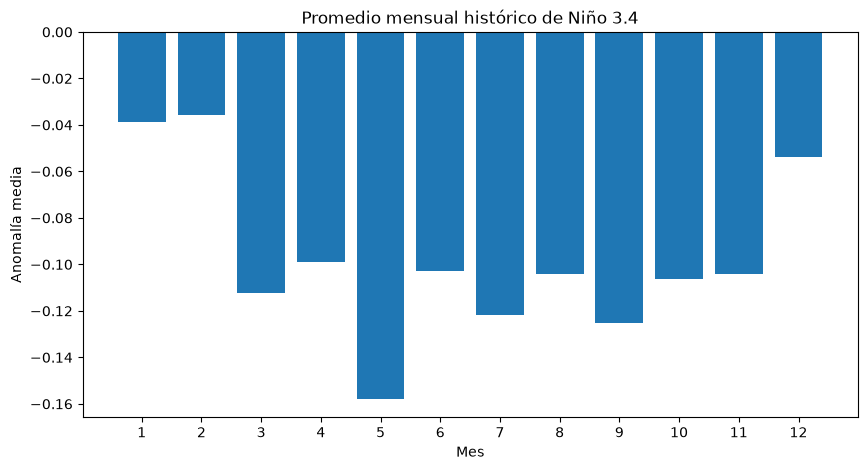

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    monthly_nino34.index,
    monthly_nino34.values
)

ax.set_title("Promedio mensual histórico de Niño 3.4")
ax.set_xlabel("Mes")
ax.set_ylabel("Anomalía media")
ax.set_xticks(range(1, 13))

plt.show()

Comprobar la variable SOI

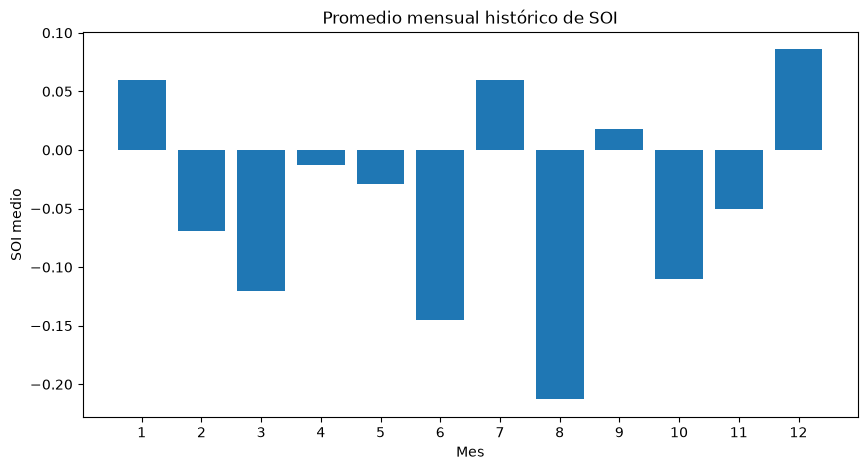

In [40]:
monthly_soi = (
    historical
    .groupby("month")["soi"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    monthly_soi.index,
    monthly_soi.values
)

ax.set_title("Promedio mensual histórico de SOI")
ax.set_xlabel("Mes")
ax.set_ylabel("SOI medio")
ax.set_xticks(range(1, 13))

plt.show()

## Conclusiones del EDA

- Los índices Niño presentan fuertes correlaciones positivas entre sí.
- SOI se relaciona negativamente con los índices Niño, especialmente con Niño 3.4.
- MEI mantiene una fuerte relación positiva con Niño 3.4 y ONI.
- ONI y Niño 3.4 son casi redundantes en el período moderno.
- TNI presenta un comportamiento distinto al resto de índices y puede aportar información complementaria.
- Las series presentan una fuerte autocorrelación a corto plazo.
- Niño 3.4 y TNI conservan una señal importante hasta aproximadamente 3 meses.
- La autocorrelación disminuye considerablemente a horizontes mayores.
- Estos resultados respaldan el uso de un horizonte de predicción de 3 meses.